# AdaBoost Regressor 1 - Theory & Mathematics of AdaBoost.R2

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn
- The AdaBoost.R2 loop **run by hand**, round by round, on real data
- How sample weights shift toward poorly-predicted rows after every round
- Where each number comes from: scaled errors → loss → beta → estimator weight
- How to verify a hand-run against scikit-learn's actual internals (`estimator_weights_`)
- Why the final prediction is a **weighted median** of all weak trees

In [1]:
# First cell = housekeeping: plotting backend, imports, reproducibility.
# Inline plotting for Jupyter; plain-Python runs fall through harmlessly.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np                  # vectors, matrices, math
import pandas as pd                 # tables (DataFrame)
import matplotlib.pyplot as plt     # low-level plotting
import seaborn as sns               # nicer defaults on top of matplotlib

from pathlib import Path            # filesystem paths that work on any OS
from sklearn.tree import DecisionTreeRegressor          # the WEAK learner we boost
from sklearn.ensemble import AdaBoostRegressor          # the full sklearn algorithm
from sklearn.utils import check_random_state             # replicates sklearn's RNG bookkeeping

np.random.seed(42)          # seed every source of randomness we control
sns.set_theme()             # seaborn's clean default look for all plots
plt.rcParams["figure.dpi"] = 100   # slightly crisper figures than the default

# ---------------------------------------------------------------------------
# DATA RULES: only real CSVs under <course>/02_machine_learning/data/.
# This helper walks UP from the current folder until it finds the course
# directory named '02_machine_learning', then points at its data/ subfolder.
# ---------------------------------------------------------------------------
def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:        # cwd, parent, grandparent, ...
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

DIABETES_CSV = DATA_DIR / "diabetes.csv"
if not DIABETES_CSV.exists():                      # download-once helper:
    from sklearn.datasets import load_diabetes     # rebuild the identical table
    load_diabetes(as_frame=True).frame.to_csv(DIABETES_CSV, index=False)

df = pd.read_csv(DIABETES_CSV)
print(df.shape)                                    # (442 rows, 11 columns)
df.head(3)

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0


## 1. The one feature we will play with

Boosting dynamics are easiest to SEE in 1-D, so we keep just `s5`
(a serum measurement, already standardised by sklearn's authors) to predict
`target` = disease progression one year after baseline. This is a REAL dataset -
no toy arrays anywhere outside pure-math illustrations.

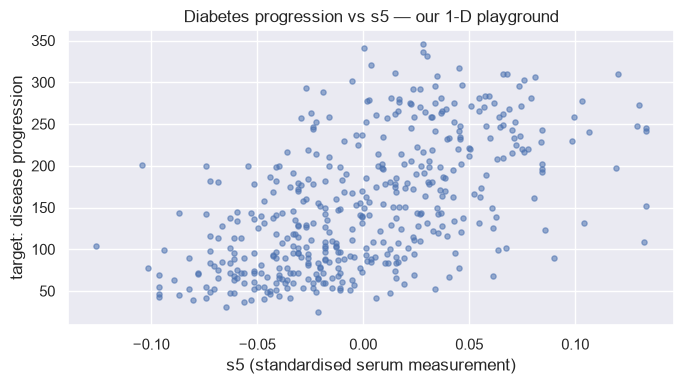

n = 442 rows | target mean = 152.1 | target std = 77.0


In [2]:
# Pull out ONE predictor column so everything fits on a single scatter plot.
X = df[["s5"]].values          # sklearn wants a 2-D matrix: shape (442, 1)
y = df["target"].values        # the number we try to predict, shape (442,)
n = len(y)                     # 442 patients

plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=14, alpha=0.55)
plt.xlabel("s5 (standardised serum measurement)")
plt.ylabel("target: disease progression")
plt.title("Diabetes progression vs s5 - our 1-D playground")
plt.tight_layout(); plt.show()

print(f"n = {n} rows | target mean = {y.mean():.1f} | target std = {y.std():.1f}")

## 2. What makes AdaBoost.R2 different from AdaBoost for classification?

In classification, errors are 0 or 1 - easy to re-weight ("you got it WRONG, look again!").
A regressor's error is a continuous number like 23.7 - how "wrong" is that?
AdaBoost.R2 (Drucker, 1997) solves this with three tricks:

1. **Scale** every absolute error by the worst absolute error of the round:
   $\tilde e_i = |e_i| / \max_j |e_j|$  →  now every scaled error lives in $[0, 1]$.
2. Reshape those scaled errors through a `loss` function (linear / square / exponential).
3. Average them **with the current row weights** into a round score
   $\bar\epsilon_m$; if $\bar\epsilon_m \ge 0.5$ the tree is DISCARDED and boosting stops.

⚠️ That early-stop rule is not a corner case - with honest stumps on hard data,
boosting often refuses to continue. We will see it live.

## 3. Hand-run, round 1 - everything from scratch

The textbook loop (weak learner trained WITH sample weights):

- weights start uniform: $w_i = 1/n$
- fit depth-1 tree $h_1$ (a single yes/no split - two leaf means)
- scaled error $\tilde e_i$, linear loss $L_i = \tilde e_i$
- weighted round score $\bar\epsilon = \sum_i w_i L_i$
- beta $\;\beta = \bar\epsilon / (1-\bar\epsilon)$  (a small "how wrong was I" ratio)
- estimator weight $\alpha = \ln(1/\beta)$  ← the tree's VOLUME when voting
- row update $w_i \leftarrow w_i \cdot e^{\alpha L_i}$, renormalise
  → big-$L$ rows (badly predicted) gain relative weight. THE adaptive move.

worst error D        = 192.01  target units
round score eps_bar  = 0.2787   (must stay below 0.5 or boosting dies)
beta                 = 0.3863
alpha (estimator wt) = 0.9510


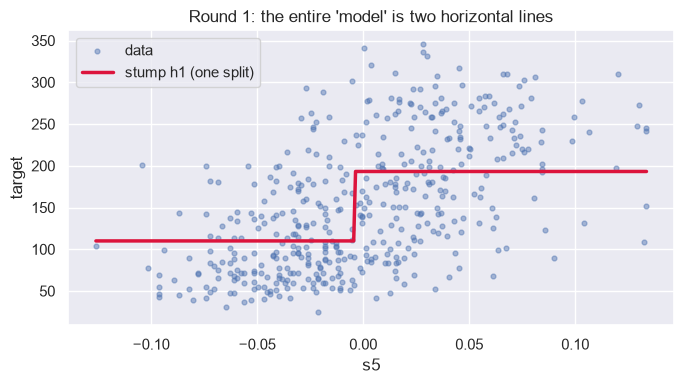

In [3]:
w = np.full(n, 1.0 / n)                       # STEP 0: equal attention for everyone

tree1 = DecisionTreeRegressor(max_depth=1)    # the weak learner: one split only
tree1.fit(X, y, sample_weight=w)              # weights are uniform, but pass them anyway
pred1 = tree1.predict(X)                      # stump prediction = 2 possible values

err_abs = np.abs(pred1 - y)                   # raw absolute residuals per row
D1 = err_abs.max()                            # worst error of this round (the scaler D)
L1 = err_abs / D1                             # LINEAR loss: scaled into [0, 1]

eps1 = float(np.sum(w * L1))                  # weighted average loss = round score
beta1 = eps1 / (1.0 - eps1)                   # classic AdaBoost.R2 ratio
alpha1 = np.log(1.0 / beta1)                  # estimator weight (voice volume)

print(f"worst error D        = {D1:.2f}  target units")
print(f"round score eps_bar  = {eps1:.4f}   (must stay below 0.5 or boosting dies)")
print(f"beta                 = {beta1:.4f}")
print(f"alpha (estimator wt) = {alpha1:.4f}")

# Show what a depth-1 tree actually is: two flat steps.
xs = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=12, alpha=0.45, label="data")
plt.plot(xs, tree1.predict(xs), color="crimson", lw=2.5, label="stump h1 (one split)")
plt.legend(); plt.xlabel("s5"); plt.ylabel("target")
plt.title("Round 1: the entire 'model' is two horizontal lines")
plt.tight_layout(); plt.show()

## 4. Rounds 2 and 3 - watch the weights migrate

Now apply the update and refit. Rows the stump missed badly get louder;
the next stump must place its single split to please THOSE rows.

round 2: eps_bar=0.2801  beta=0.3891  alpha=0.9440
round 3: eps_bar=0.3814  beta=0.6167  alpha=0.4834


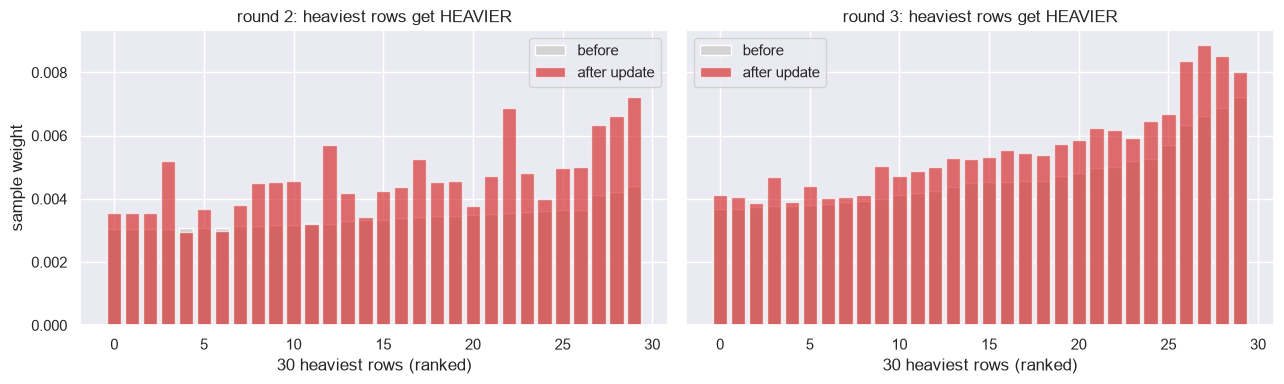

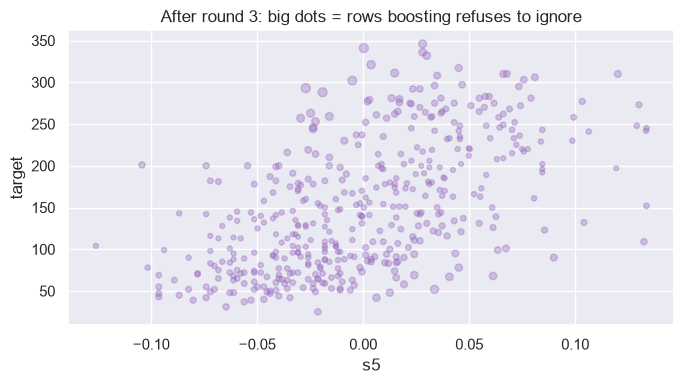

In [4]:
history = [dict(round=1, w_before=w.copy(), alpha=alpha1, eps=eps1)]

w = w * np.exp(alpha1 * L1)      # THE update: multiply by exp(alpha * loss_i)
w = w / w.sum()                  # renormalise so weights still sum to 1

for rnd in [2, 3]:
    w_before = w.copy()
    tree_r = DecisionTreeRegressor(max_depth=1).fit(X, y, sample_weight=w)
    pred_r = tree_r.predict(X)
    err_abs = np.abs(pred_r - y)
    Lr = err_abs / err_abs.max()              # scale by THIS round's worst error
    eps_r = float(np.sum(w * Lr))
    beta_r = eps_r / (1.0 - eps_r)
    alpha_r = np.log(1.0 / beta_r)
    history.append(dict(round=rnd, w_before=w_before, alpha=alpha_r, eps=eps_r))
    print(f"round {rnd}: eps_bar={eps_r:.4f}  beta={beta_r:.4f}  alpha={alpha_r:.4f}")
    w = w * np.exp(alpha_r * Lr)              # prepare weights for the NEXT round
    w = w / w.sum()
    history[-1]["w_after"] = w.copy()         # snapshot AFTER this round's update

# Visual proof of adaptation: which rows gained the most weight?
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, h in zip(axes, history[1:]):          # rounds 2 and 3 (history[0] is round 1)
    idx = np.argsort(h["w_before"])           # rank rows by weight BEFORE the round
    top = idx[-30:]                           # the 30 loudest rows entering this round
    ax.bar(range(30), h["w_before"][top], color="lightgray", label="before")
    ax.bar(range(30), h["w_after"][top], color="tab:red", alpha=0.65, label="after update")
    ax.set_title(f"round {h['round']}: heaviest rows get HEAVIER")
    ax.set_xlabel("30 heaviest rows (ranked)")
    ax.legend()
axes[0].set_ylabel("sample weight")
plt.tight_layout(); plt.show()
# 💡 Every red bar ≥ its gray neighbour: mass keeps flowing toward hard rows.

# Same story on the data itself: dot SIZE = weight after round 3.
plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=8 + 4000 * w, alpha=0.35, color="tab:purple")
plt.xlabel("s5"); plt.ylabel("target")
plt.title("After round 3: big dots = rows boosting refuses to ignore")
plt.tight_layout(); plt.show()

## 5. Reality check - does sklearn compute the SAME numbers?

Almost, with ONE implementation detail worth knowing: modern sklearn does not pass
`sample_weight` into the tree directly. Each round it draws a **weighted bootstrap**
sample (rows chosen WITH replacement, probability = current weights) and fits an
unweighted tree on that resample. Statistically the same idea; numerically slightly
different trees. Let us replicate sklearn exactly, RNG quirks included:

In [5]:
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=3, loss="linear", learning_rate=1.0, random_state=42,
).fit(X, y)

print("sklearn estimator_weights_ :", ada.estimator_weights_)
print("sklearn estimator_errors_  :", ada.estimator_errors_)

# --- exact replication -----------------------------------------------------
rs = check_random_state(42)                    # same RandomState object sklearn builds
w_rep = np.full(n, 1.0 / n)
alphas_rep, eps_rep = [], []

for m in range(3):
    rs.randint(np.iinfo(np.int32).max)         # sklearn burns one randint to seed each tree
    boot = rs.choice(n, size=n, replace=True, p=w_rep)   # weighted bootstrap indices
    t = DecisionTreeRegressor(max_depth=1).fit(X[boot], y[boot])   # UNweighted fit
    p = t.predict(X)                            # but scored on ALL original rows
    L = np.abs(p - y); L /= L.max()             # linear loss in [0, 1]
    eps = float(np.sum(w_rep * L))              # weighted average loss
    b = eps / (1.0 - eps)
    alphas_rep.append(np.log(1.0 / b))          # alpha = ln(1/beta), lr folded in
    eps_rep.append(eps)
    w_rep *= b ** (1.0 - L)                     # sklearn's form: beta^(1-L) ≡ exp(-α(1-L))
    w_rep /= w_rep.sum()                        # (identical after normalisation)

match_w = np.allclose(alphas_rep, ada.estimator_weights_)
match_e = np.allclose(eps_rep, ada.estimator_errors_)
print(f"manual alphas : {np.round(alphas_rep, 6)}")
print(f"manual errors : {np.round(eps_rep, 6)}")
print(f"weights match: {match_w} | errors match: {match_e}")
assert match_w and match_e, "hand-run diverged from sklearn!"
# 💡 Note the equivalence used above:  beta**(1-L) == exp(ln(beta)*(1-L)) == exp(-α*(1-L)).
#    Multiplying good rows DOWN by exp(-α(1-L)) or bad rows UP by exp(α*L) differ only by a
#    constant factor exp(-α), which vanishes at the next normalisation. Same algorithm.

sklearn estimator_weights_ : [0.90443019 0.71750956 0.84718905]
sklearn estimator_errors_  : [0.28814094 0.32794163 0.30002285]
manual alphas : [0.90443  0.71751  0.847189]
manual errors : [0.288141 0.327942 0.300023]
weights match: True | errors match: True


## 6. The final prediction is a weighted MEDIAN (not mean!)

To predict, sklearn collects every tree's guess and takes the median of the guesses,
where each tree carries a vote of size `estimator_weights_[m]`. Medians are robust:
one hallucinating tree cannot drag the answer the way a mean could.

In [6]:
# Reproduce ada.predict() manually with a weighted median, step by step.
P = np.column_stack([est.predict(X) for est in ada.estimators_])   # (442 rows, 3 trees)
votes = ada.estimator_weights_.astype(float)   # vote size per tree - sklearn uses the
                                               # RAW weights here (no exp!), see
                                               # _get_median_predict in the source

order = np.argsort(P, axis=1)                # sort each row's three guesses
sorted_P = np.take_along_axis(P, order, axis=1)
sorted_v = votes[order]                      # carry each vote along with its guess
cum = np.cumsum(sorted_v, axis=1)            # running total of votes
cutoff = cum[:, -1][:, None] / 2.0           # half of the total vote mass
pick = np.argmax(cum >= cutoff, axis=1)      # first guess where we pass the halfway mark
manual_median = sorted_P[np.arange(n), pick]

print("max |manual - sklearn.predict| =", np.abs(manual_median - ada.predict(X)).max())
assert np.allclose(manual_median, ada.predict(X))

max |manual - sklearn.predict| = 0.0


## 7. One dataset, three losses

The ONLY thing `loss` changes is the reshaping of scaled errors before averaging:

- `"linear"`: `L = e_tilde` - proportional blame
- `"square"`: `L = e_tilde²` - big misses blamed disproportionately more  
- `"exponential"`: `L = 1 − exp(−e_tilde)` - compressed, gentlest, longest runs

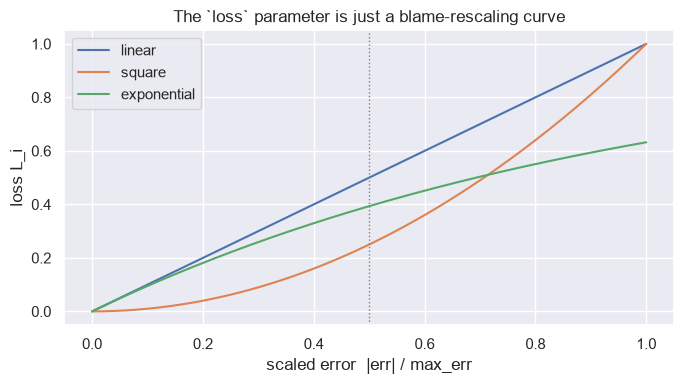

loss=linear       ->  13 of 300 rounds survived
loss=square       ->  12 of 300 rounds survived
loss=exponential  ->  39 of 300 rounds survived


In [7]:
e_tilde = np.linspace(0, 1, 200)             # every possible scaled error
plt.figure(figsize=(7, 4))
plt.plot(e_tilde, e_tilde, label="linear")
plt.plot(e_tilde, e_tilde ** 2, label="square")
plt.plot(e_tilde, 1 - np.exp(-e_tilde), label="exponential")
plt.axvline(0.5, color="gray", ls=":", lw=1)
plt.xlabel("scaled error  |err| / max_err"); plt.ylabel("loss L_i")
plt.title("The `loss` parameter is just a blame-rescaling curve")
plt.legend(); plt.tight_layout(); plt.show()

# Empirically: exponential keeps boosting alive far longer on this dataset.
for loss_name in ["linear", "square", "exponential"]:
    m = AdaBoostRegressor(DecisionTreeRegressor(max_depth=1), n_estimators=300,
                          loss=loss_name, random_state=42).fit(X, y)
    print(f"loss={loss_name:<12} -> {len(m.estimators_):>3} of 300 rounds survived")

## Summary takeaways

- AdaBoost.R2 scales errors by the round's worst error, converts them to losses,
  averages them into a round score, and turns it into an estimator voice `ln(1/β)`.
- The row-weight update `w *= exp(α·L)` is the whole trick: every new stump
  concentrates on what the ensemble still gets wrong.
- If a round scores `ε̄ ≥ 0.5`, sklearn throws the tree away and STOPS EARLY -
  always inspect `len(model.estimators_)`.
- Final predictions are a vote-weighted MEDIAN of the stumps (we reproduced it
  exactly - and learned that sklearn votes with RAW estimator weights, no exp).
- Our hand-run matched `estimator_weights_` / `estimator_errors_` to machine precision -
  once you mimic sklearn's weighted-bootstrap detail (and its RNG stream!).